## Think about which cases from the table above could also be formulated as a classification and regression task. Provide an answer in the project notebook.

1. Regression
2. Classification
3. Regression or classification for per day
4. MultiClassification
5. Classification
6. Classification
7. Multiclassification
8. Regression
9. Clustering(Cplassification)
10. Classification

# 1. Itroduction

## i. Для начала, пожалуйста, напишите 5 примеров применения методов машинного обучения в жизни. Какую пользу приносит использование методов машинного обучения в каждом из ваших примеров?

1. Распознование раковых и других злокачественных опухолей на рентгене. Человеческий глаз не всегда может уловить все маленькие точки и образование, а применяя модель, она может подсказыват на что обратить внимаение, чтобы не пропустить ничего.
2. Все методы рекомендаций, будь то музыка или фильмы или товары. Позволяет автоматизировать процесс рекомендаций для получения выгоды.
3. Автопилоты автомобилей, чтобы автопилот мог передвигаться не только по размеченным дорогам и определённым маршрутам, а мог правильно поступать в нестандарных ситуациях, которых раньше не видел.
4. Видео распознование объектов, или каких-либо действий, что очень важно как в военном сегменте, так и в бизнесе, для безопасности и контролируемости процессов.
5. Выявлеине дефектов в апаратуре или других сложных и дорогостоящих приборах, где важно предсказать пеломоку и провести оценочные работы дли снижения экономических затрат.

## ii. Используйте классификацию задач во введении, чтобы решить, какой класс вы можете назначить задачам из таблицы выше и 5 предоставленным вами примерам.

1. Классификация - 2, 4(мультикласс), 5, 6, 8, 10, распознование опухолей, multilabel для рекомендаций, распознование объектов, выявление дефектов.
2. Регрессия - 1, 3
3. Dimensionality reduction(снижение размерности) - 5, 9
4. Association - 5
5. Clustering - 5

## iii. Подумайте, в чем разница между multiclass и multilabel.

1. Multiclass - есть четкое разделение на класы и каждому объекту не может быть присвоено больше чем 1 класс. При это классов должно быть больше 2.
2. Multilabel - когда объекту можно присвоить несоклько меток класса, напирмер жанры фильмов, то есть классы не являются взаимоисключающими.

## iv. Является ли пример с ценами на жильё из теории классификацией задачи регрессии? Можно ли свести задачу регрессии к классификации?

1. Пример с предсказыванием цен на дома является задачей регрессии, так как предсказываем цену. 

2. Задачу регресси можно свести к задаче класфификации, преобразовав выражения для вычисления в такому виду, что они будут предсказывать вероятность принадлежности классу 1. И тогда положив, что если модель предсказывает более чем 0,5, тогда говорить, что это класс 1, иначе 0.

# 2. Itroduction to Data Analysis

## i. import libraries

In [1]:
import pandas as pd
import numpy as np
import scipy
import statsmodels
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

## ii. Load data

In [2]:
df = pd.read_json('data/train.json')

## iii. what is the size ?

In [3]:
df.shape

(49352, 15)

## iv. Print the list of cilumns. Which column is target?

In [4]:
df.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

target column is 'price'

v. Make a quick analysis of the data: use the methods info(), describe(), corr(). Explain the results of the outputs. Are there any empty columns?

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


Видно что нет пустых значений, так как по каждому столбцу не нулевых значений 49352, что соотвествует расмерности всей таблицы. Видим много столбцов типа object(9 штук), и по 3 штуки float и int. Общее количество столбцов 15.

In [6]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


Тут метод описывает опиысвает столбцы с численными занчениями. Видим средние, максимальные, минимальные значения. 

In [7]:
df.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


Таблица корреляции, но только для чиловых столбцов пока что.

Видим большую корреляцию между количсетво ванных комнат и спален. 

Также слиьная корреляция между широтой и доготой, то есть территорияльное нахождение дома, что конечно врятли может дать полезные данные.

Стоит отметить, что корреляция цены с количсетвом спален и ванных комнат значительно выше, чем с другими пирзнаками, что может говорить о большем влияне цену.

## vi. We'll work with only 3 features: 'bathrooms', 'bedrooms', 'interest_level' and with the target column 'price'. Create a dataframe with only these columns.

In [8]:
work_df = df[['bathrooms', 'bedrooms', 'interest_level', 'price']]
work_df.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


# 3. Statical Data Analysis

## Tagret Analysis

### a. Plot a histogram to understand the distribution of the target. Is it all clear?

Text(0.5, 1.0, 'Histogram')

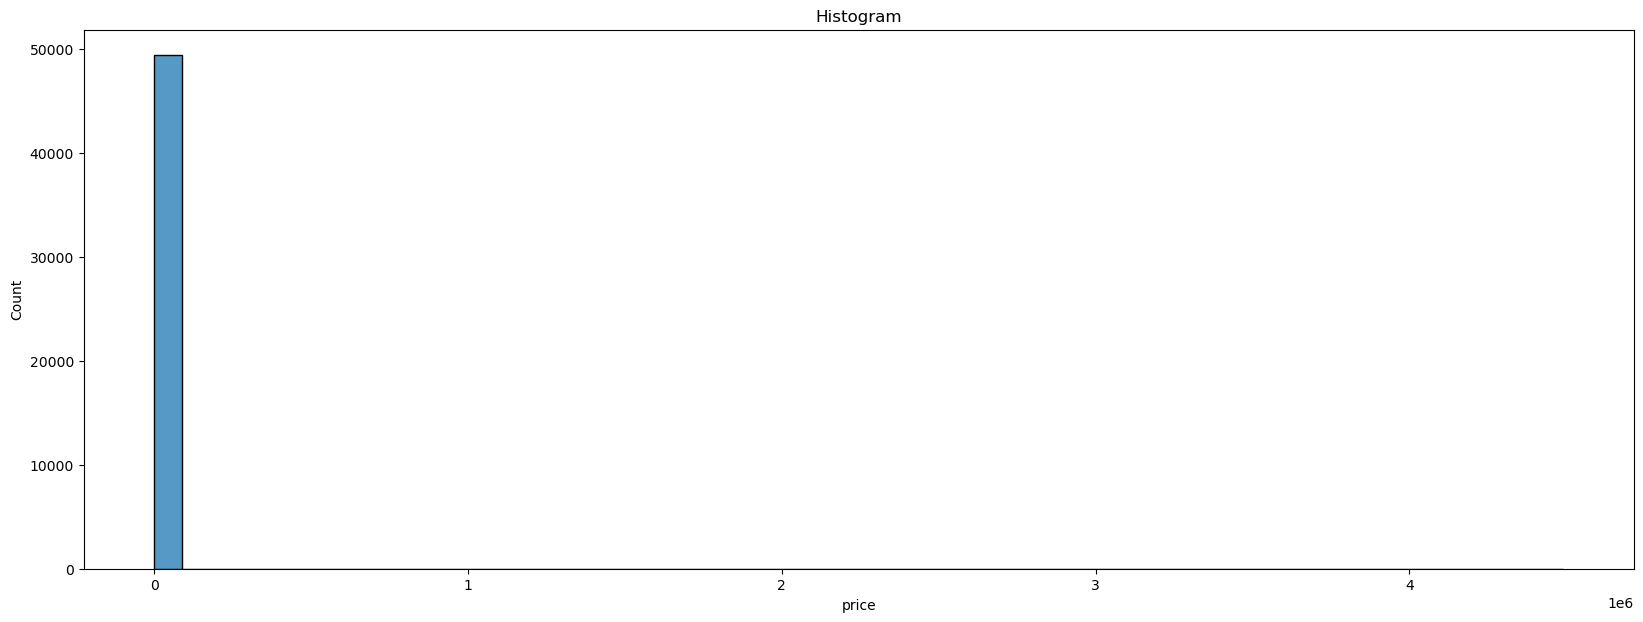

In [9]:
plt.figure(figsize=(20,7))
sns.histplot(data=work_df.price, bins=50)
plt.title('Histogram')

### b. The next step is boxplot(). What can you say about the target? Are there any outliers?

Text(0.5, 1.0, 'Boxplot')

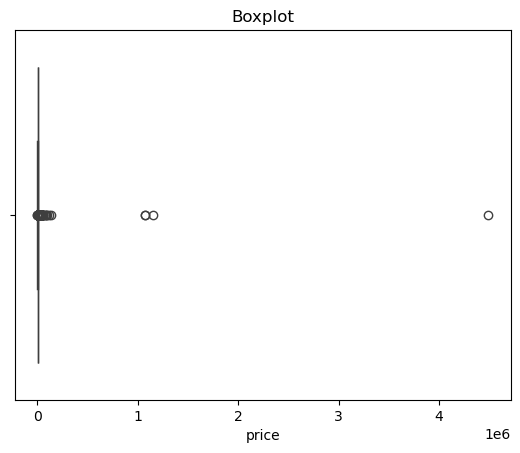

In [10]:
sns.boxplot(data=work_df.price, orient='h')
plt.title('Boxplot')


boxplot показывает нам выбросы, причём очень и очень сильные.

### c. Drop the rows that are outside the 1 and 99 percentiles from the target column.

In [11]:
work_df = work_df[(work_df.price < np.percentile(work_df.price, 99)) & (work_df.price > np.percentile(work_df.price, 1))] 

### d. Plot another histogram for price. Explain the result.

<Axes: xlabel='price', ylabel='Count'>

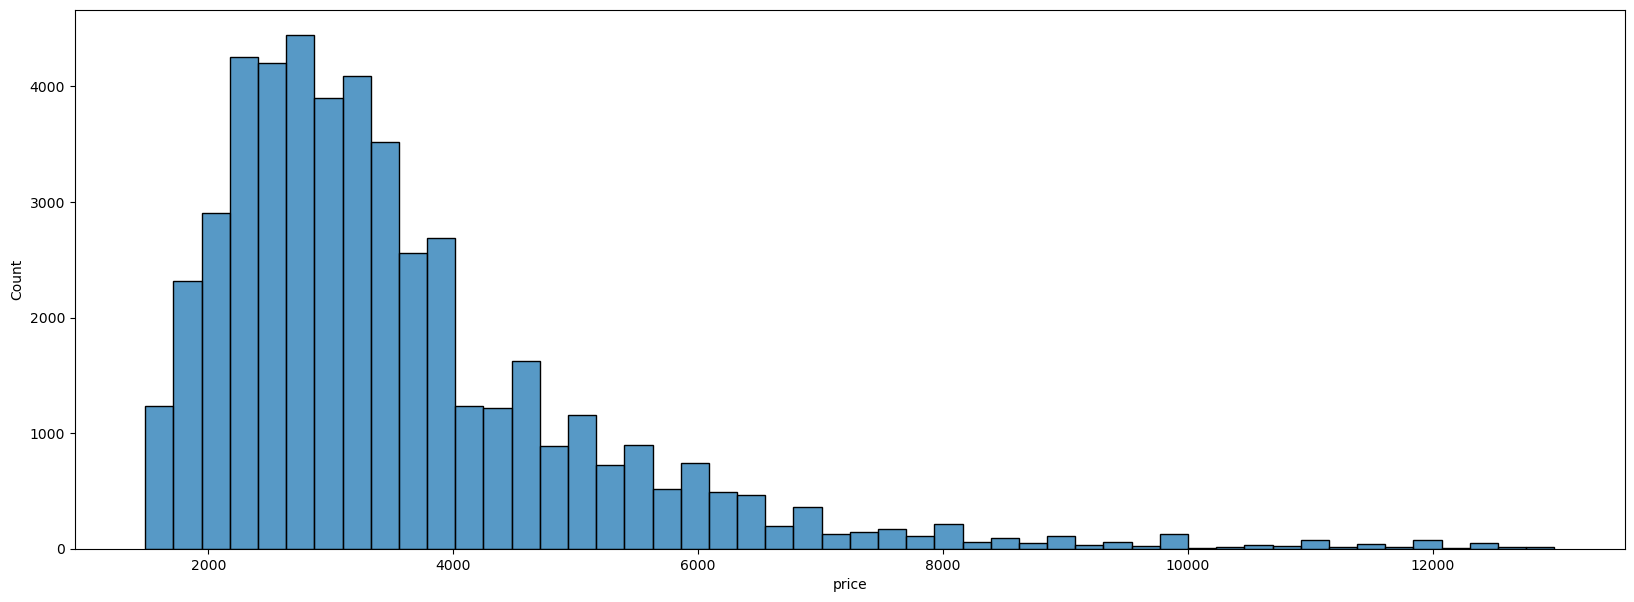

In [12]:
plt.figure(figsize=(20,7))
sns.histplot(data=work_df.price, bins=50)

Удаление выбросов позволило лучше визаулизировать распределенние данных. Как видно, наибольшее количество примеров расположено в районе от 1500 до 6000 тысяч. Далее количество примерно одиннаковое. Удаление выбросов очень важно для корректной работы модели, особенно тех, которые работают на градиентном спуске, и которые пытаются найти апроксимирующую кривую, выбросы будут сильно мешать.

## iv. Characteristics Analysis

### a. What is the type of column 'interest_level'? - Answer: Object

In [13]:
work_df.interest_level.info()

<class 'pandas.core.series.Series'>
Index: 48343 entries, 4 to 124009
Series name: interest_level
Non-Null Count  Dtype 
--------------  ----- 
48343 non-null  object
dtypes: object(1)
memory usage: 755.4+ KB


### b. Print the values in this column. How many entries does each value contain?
3 differetn values

In [14]:
work_df.interest_level.value_counts()

interest_level
low       33672
medium    11114
high       3557
Name: count, dtype: int64

### c. Encode these values. For example, you can replace each value with 0, 1, or 2.

In [15]:
interest_level_dict_encode = {
    'low' : 0,
    'medium' : 1,
    'high' : 2
}

work_df['interest_level'] = [interest_level_dict_encode[x] for x in work_df.interest_level] 
work_df.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,1,2400
6,1.0,2,0,3800
9,1.0,2,1,3495
10,1.5,3,1,3000
15,1.0,0,0,2795


### d. Plot histograms for the features 'bathrooms', 'bedrooms'. Are there any outliers?

Text(0.5, 1.0, 'Bathrooms')

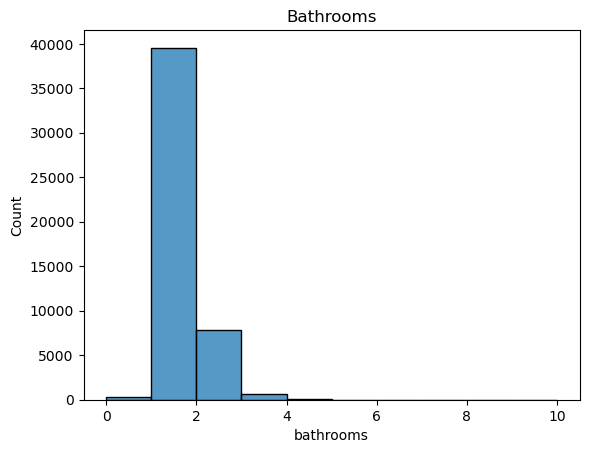

In [16]:
sns.histplot(data=work_df.bathrooms, bins=10)
plt.title('Bathrooms')

Text(0.5, 1.0, 'Bedrooms')

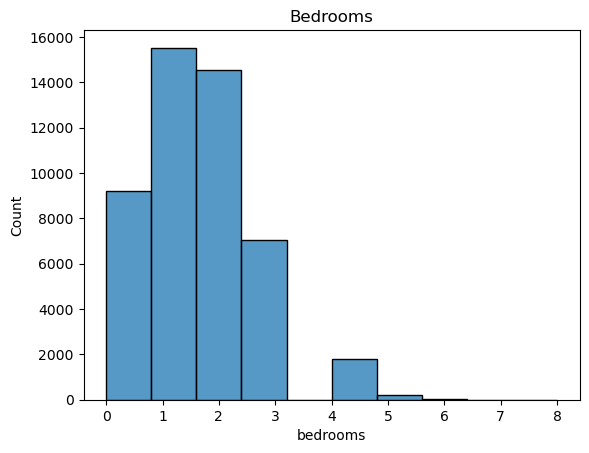

In [17]:
sns.histplot(data=work_df.bedrooms, bins=10)
plt.title('Bedrooms')

Answer: Никаких выбросов для спален или ванных комнат нет.

## Complex analysis

### a. Plot a correlation matrix to understand the correlation between features and target. Plot a heat map for the correlation matrix. Is there a correlation?

In [18]:
correlation_matrix = work_df.corr(numeric_only=True)
correlation_matrix

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517200,-0.062819,0.670808
bedrooms,0.517200,1.000000,0.051282,0.547310
interest_level,-0.062819,0.051282,1.000000,-0.199652
price,0.670808,0.547310,-0.199652,1.000000


Text(0.5, 1.0, 'Correlation matrix')

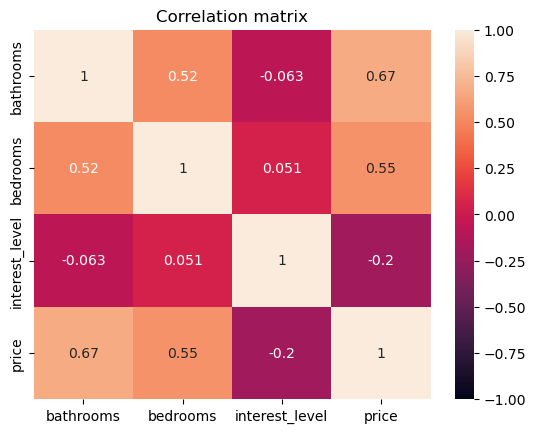

In [19]:
sns.heatmap(correlation_matrix, annot=True, vmin=-1, vmax=1)
plt.title('Correlation matrix')

Корреляция между ценой и ванными комнатами самая большая, несколько меншье с количеством спален. При этом с уровнем интереса корреляция отрицательная и сильно меньше по модулю.

### b. Plot a scatterplot to visualize the correlation between the features and the target. You should return 3 plots where the X-axis is the target and the Y-axis is a feature.

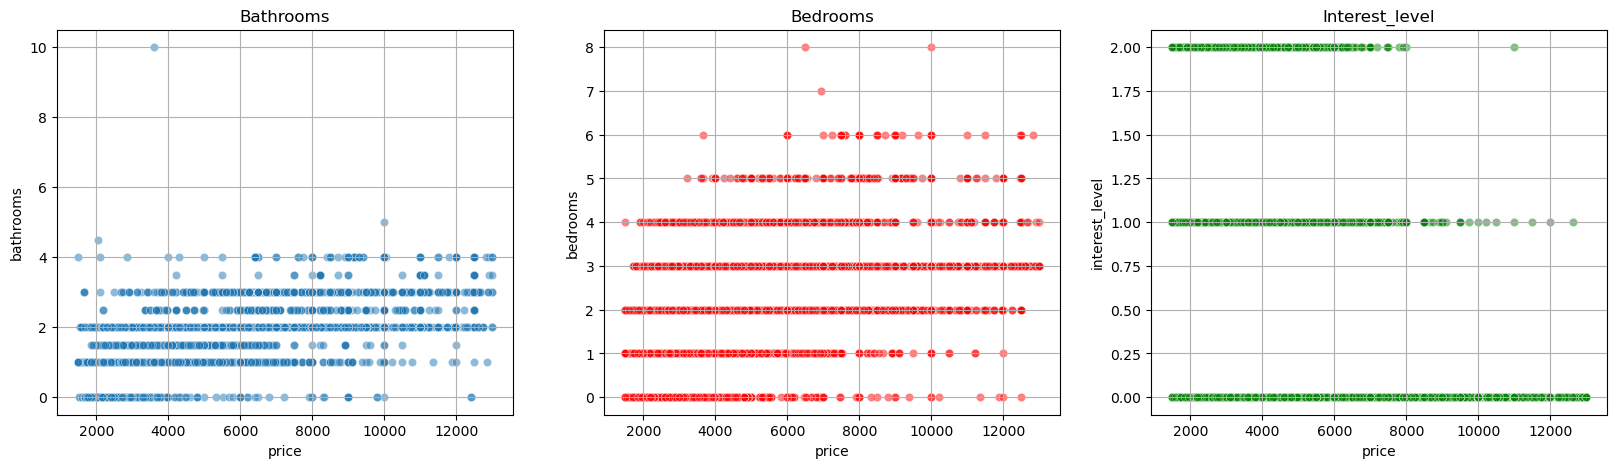

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5))

sns.scatterplot(data=work_df, x='price', y='bathrooms', ax=ax[0], alpha=0.5)
ax[0].set_title('Bathrooms')
ax[0].grid(True)

sns.scatterplot(data=work_df, x='price', y='bedrooms', ax=ax[1], c='r', alpha=0.5)
ax[1].set_title('Bedrooms')
ax[1].grid(True)

sns.scatterplot(data=work_df, x='price', y='interest_level', ax=ax[2], c='g', alpha=0.5)
ax[2].set_title('Interest_level')

ax[2].grid(True)

# Creating Features

## i. This step is very broad. You can create as many features as you want. For example, you can add 3 new features that are squared: 'bathrooms_squared', 'bedrooms_squared', ''interest_level_squared'. Plot a correlation matrix with the new features. Are the new features more correlated with the target than the basic features?

In [21]:
many_f_df = work_df.copy()
many_f_df['bathrooms_squared'] = work_df.bathrooms * work_df.bathrooms
many_f_df['bedrooms_squared'] = work_df.bedrooms * work_df.bedrooms
many_f_df['interest_level_squared'] = work_df.interest_level * work_df.interest_level
many_f_df.head()

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
4,1.0,1,1,2400,1.00,1,1
6,1.0,2,0,3800,1.00,4,0
9,1.0,2,1,3495,1.00,4,1
10,1.5,3,1,3000,2.25,9,1
15,1.0,0,0,2795,1.00,0,0


In [22]:
many_f_df.corr(numeric_only=True)

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.517200,-0.062819,0.670808,0.955906,0.548426,-0.058710
bedrooms,0.517200,1.000000,0.051282,0.547310,0.478497,0.928282,0.040125
interest_level,-0.062819,0.051282,1.000000,-0.199652,-0.067757,0.047048,0.943959
price,0.670808,0.547310,-0.199652,1.000000,0.646949,0.544612,-0.182283
bathrooms_squared,0.955906,0.478497,-0.067757,0.646949,1.000000,0.521951,-0.061563
bedrooms_squared,0.548426,0.928282,0.047048,0.544612,0.521951,1.000000,0.036408
interest_level_squared,-0.058710,0.040125,0.943959,-0.182283,-0.061563,0.036408,1.000000


Text(0.5, 1.0, 'Correlation matrix')

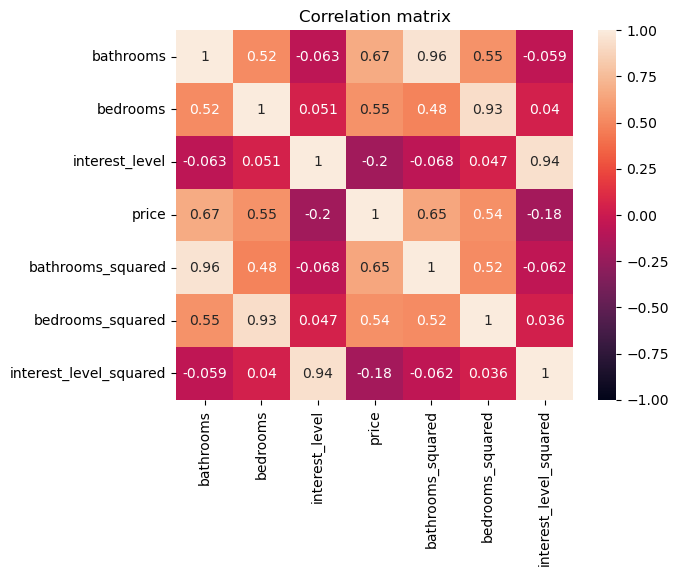

In [23]:
sns.heatmap(many_f_df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1)
plt.title('Correlation matrix')

У новых признаков корреляция с ценой не выше, а чуть ниже.

## vi. Apply PolynomialFeatures() to fit and transform your training and test data.

In [24]:
df_train = pd.read_json('data/train.json')
df_test = pd.read_json('data/test.json')

In [25]:
df_train = df_train[(df_train.price < np.percentile(df_train.price, 99)) & (df_train.price > np.percentile(df_train.price, 1))]

In [26]:
df_test = df_test[(df_test.price < np.percentile(df_test.price, 99)) & (df_test.price > np.percentile(df_test.price, 1))]
df_test = df_test[df_test.bathrooms < 20]
df_test.bathrooms.value_counts()

bathrooms
1.0    58882
2.0    11450
1.5      997
3.0      837
0.0      447
2.5      371
4.0       96
3.5       41
5.0        3
6.0        2
6.5        1
Name: count, dtype: int64

In [27]:
X_train = df_train[['bathrooms', 'bedrooms']]
y_train = df_train['price']
del df_train

X_test = df_test[['bathrooms', 'bedrooms']]
y_test = df_test['price']
del df_test

In [28]:
poly = PolynomialFeatures(degree=10)

In [29]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

# 5. Now you need to train 3 models: linear regression, decision tree and naive model. 

### Create two empty Pandas DataFrames with columns 'model', 'train', 'test'. 

In [30]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

In [31]:
linear = LinearRegression()
tree = DecisionTreeRegressor(random_state=21)

models = {'linear_regression' : linear, 'decision_tree' : tree}

for name, model in models.items():
    model.fit(X_train_poly, y_train)
    predict_train = model.predict(X_train_poly)
    predict_test = model.predict(X_test_poly)

    mae_train = mean_absolute_error(y_train, predict_train)
    mae_test = mean_absolute_error(y_test, predict_test)

    rmse_train = root_mean_squared_error(y_train, predict_train)
    rmse_test = root_mean_squared_error(y_test, predict_test)

    mae_row = pd.DataFrame({'model' : [name], 'train' : [mae_train], 'test' : [mae_test]})
    rmse_row = pd.DataFrame({'model' : [name], 'train' : [rmse_train], 'test' : [rmse_test]})

    result_MAE = pd.concat([result_MAE, mae_row], ignore_index=True)
    result_RMSE = pd.concat([result_RMSE, rmse_row], ignore_index=True)

C:\Users\User\AppData\Local\Temp\ipykernel_19772\3014761491.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_MAE = pd.concat([result_MAE, mae_row], ignore_index=True)
C:\Users\User\AppData\Local\Temp\ipykernel_19772\3014761491.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_RMSE = pd.concat([result_RMSE, rmse_row], ignore_index=True)


In [32]:
y_train_pred = np.full_like(y_train, np.mean(y_train))
y_test_pred = np.full_like(y_test, np.mean(y_test))

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_train = root_mean_squared_error(y_train, y_train_pred)
rmse_test = root_mean_squared_error(y_test, y_test_pred)

mae_row = pd.DataFrame({'model' : ['mean'], 'train' : [mae_train], 'test' : [mae_test]})
rmse_row = pd.DataFrame({'model' : ['mean'], 'train' : [rmse_train], 'test' : [rmse_test]})

result_MAE = pd.concat([result_MAE, mae_row], ignore_index=True)
result_RMSE = pd.concat([result_RMSE, rmse_row], ignore_index=True)

In [33]:
y_train_pred = np.full_like(y_train, np.median(y_train))
y_test_pred = np.full_like(y_test, np.median(y_test))

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_train = root_mean_squared_error(y_train, y_train_pred)
rmse_test = root_mean_squared_error(y_test, y_test_pred)

mae_row = pd.DataFrame({'model' : ['median'], 'train' : [mae_train], 'test' : [mae_test]})
rmse_row = pd.DataFrame({'model' : ['median'], 'train' : [rmse_train], 'test' : [rmse_test]})

result_MAE = pd.concat([result_MAE, mae_row], ignore_index=True)
result_RMSE = pd.concat([result_RMSE, rmse_row], ignore_index=True)

In [34]:
result_MAE

,model,train,test
0,linear_regression,753.675999,1944.027194
1,decision_tree,753.675997,756.432418
2,mean,1134.316695,1128.724110
3,median,1082.220859,1078.660235


In [35]:
result_RMSE

,model,train,test
0,linear_regression,1070.598967,180245.016147
1,decision_tree,1070.598967,1073.411607
2,mean,1585.609108,1573.234943
3,median,1631.719953,1617.920212


Best model is Decision Tree Classifier